# DEFT Loss v4: mild weighted-loss OOF score stacking

This notebook combines the `mild_w1_5_w2_1p5` weighted-loss idea with the v4 OOF score-stacking method.

- Input: same as `04_similarity_feature_mlp_confidence.ipynb`
- Base models: 04-style MLP trained with confidence 1/2 mild loss weights
- OOF scores: 5-class MLP probabilities and binary 123 vs 45 MLP probabilities
- Stackers: OOF logistic stacker and OOF ridge stacker
- Thresholds: separate threshold choices by objective

In [1]:
from pathlib import Path
import json
import pickle
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

SEED = 42
N_SPLITS = 5
BATCH_SIZE = 128
EPOCHS = 100
LR = 1e-3
WEIGHT_DECAY = 1e-4
HIDDEN_DIM = 32
DROPOUT = 0.2
LABELS = [1, 2, 3, 4, 5]

# Selected from the previous sweep as the best balanced operating point.
LOSS_WEIGHTS = {1: 5.0, 2: 1.5, 3: 1.0, 4: 1.0, 5: 1.0}

DENSE_THRESHOLDS_01 = np.linspace(0.0, 1.0, 1001)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
print('DEVICE:', DEVICE)
print('LOSS_WEIGHTS:', LOSS_WEIGHTS)

DEVICE: cuda
LOSS_WEIGHTS: {1: 5.0, 2: 1.5, 3: 1.0, 4: 1.0, 5: 1.0}


In [2]:
try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd().resolve()

if HERE.name == 'deft논문기반_실험':
    EXP_DIR = HERE
    ROOT = HERE.parent
else:
    ROOT = HERE
    EXP_DIR = ROOT / 'deft논문기반_실험'

METADATA_CSV = ROOT / 'data' / 'metadata' / 'BSD10k_metadata.csv'
AUDIO_EMB_DIR = ROOT / 'data' / 'features' / 'clap_audio_embeddings'
TEXT_EMB_DIR = ROOT / 'data' / 'features' / 'clap_text_embeddings'
TEXT_SIM_CSV = EXP_DIR / 'audio_text_sim_confidence_outputs' / 'audio_text_similarity_with_bin_predictions.csv'
CLASS_SIM_CSV = EXP_DIR / 'audio_class_sim_confidence_outputs' / 'audio_class_similarity_with_bin_predictions.csv'
MARGIN_CSV = EXP_DIR / 'clap_similarity_margin_outputs' / 'clap_similarity_margin_features.csv'

OUT_DIR = EXP_DIR / 'deft_loss_v4_outputs'
PLOT_DIR = OUT_DIR / 'plots'
REPORT_DIR = OUT_DIR / 'reports'
PRED_DIR = OUT_DIR / 'predictions'
MODEL_DIR = OUT_DIR / 'models'
for p in [PLOT_DIR, REPORT_DIR, PRED_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

for p in [METADATA_CSV, AUDIO_EMB_DIR, TEXT_EMB_DIR, TEXT_SIM_CSV, CLASS_SIM_CSV, MARGIN_CSV]:
    print(p, 'exists:', p.exists())
print('OUT_DIR:', OUT_DIR)

C:\Users\solok\Desktop\Dcase baseline\data\metadata\BSD10k_metadata.csv exists: True
C:\Users\solok\Desktop\Dcase baseline\data\features\clap_audio_embeddings exists: True
C:\Users\solok\Desktop\Dcase baseline\data\features\clap_text_embeddings exists: True
C:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\audio_text_sim_confidence_outputs\audio_text_similarity_with_bin_predictions.csv exists: True
C:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\audio_class_sim_confidence_outputs\audio_class_similarity_with_bin_predictions.csv exists: True
C:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\clap_similarity_margin_outputs\clap_similarity_margin_features.csv exists: True
OUT_DIR: C:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\deft_loss_v4_outputs


## Build the same features as 04

In [3]:
SCALAR_FEATURE_COLS = [
    'audio_text_sim',
    'audio_class_sim',
    'audio_assigned_label_margin',
    'text_assigned_label_margin',
]
FEATURE_DESCRIPTION = 'audio_embedding_512 + text_embedding_512 + class_one_hot + similarity_margin_4'
MODEL_DESCRIPTION = 'Linear(input_dim, 32) -> ReLU -> Dropout(0.2) -> Linear(32, output_dim)'

meta = pd.read_csv(METADATA_CSV)
audio_paths = {p.stem: p for p in AUDIO_EMB_DIR.glob('*.npy')}
text_paths = {p.stem: p for p in TEXT_EMB_DIR.glob('*.npy')}

rows, audio_list, text_list = [], [], []
for _, row in meta.iterrows():
    sound_id = str(row['sound_id'])
    if sound_id not in audio_paths or sound_id not in text_paths:
        continue
    try:
        confidence = int(row['confidence'])
    except Exception:
        continue
    if confidence not in LABELS:
        continue
    rows.append({'sound_id': sound_id, 'class': row['class'], 'confidence': confidence})
    audio_list.append(np.load(audio_paths[sound_id]).reshape(-1).astype(np.float32))
    text_list.append(np.load(text_paths[sound_id]).reshape(-1).astype(np.float32))

df = pd.DataFrame(rows)
df['_row_idx'] = np.arange(len(df))
audio_emb = np.stack(audio_list).astype(np.float32)
text_emb = np.stack(text_list).astype(np.float32)

text_sim_df = pd.read_csv(TEXT_SIM_CSV)[['sound_id', 'audio_text_sim']]
class_sim_df = pd.read_csv(CLASS_SIM_CSV)[['sound_id', 'audio_class_sim']]
margin_df = pd.read_csv(MARGIN_CSV)[['sound_id', 'audio_assigned_label_margin', 'text_assigned_label_margin']]
for part_df in [text_sim_df, class_sim_df, margin_df]:
    part_df['sound_id'] = part_df['sound_id'].astype(str)

df = df.merge(text_sim_df, on='sound_id', how='left')
df = df.merge(class_sim_df, on='sound_id', how='left')
df = df.merge(margin_df, on='sound_id', how='left')
missing_scalar = int(df[SCALAR_FEATURE_COLS].isna().any(axis=1).sum())
df = df.dropna(subset=SCALAR_FEATURE_COLS).reset_index(drop=True)

keep_idx = df['_row_idx'].to_numpy(dtype=np.int64)
audio_emb = audio_emb[keep_idx]
text_emb = text_emb[keep_idx]
scalar_features = df[SCALAR_FEATURE_COLS].to_numpy(dtype=np.float32)

class_categories = sorted(df['class'].unique().tolist())
class_to_idx = {name: idx for idx, name in enumerate(class_categories)}
class_ids = df['class'].map(class_to_idx).to_numpy(dtype=np.int64)
class_onehot = np.eye(len(class_categories), dtype=np.float32)[class_ids]

X_full = np.concatenate([audio_emb, text_emb, class_onehot, scalar_features], axis=1).astype(np.float32)
y_confidence = df['confidence'].to_numpy(dtype=np.int64)
y_5class = y_confidence - 1
y_binary = (y_confidence >= 4).astype(np.int64)
df['target_high_confidence'] = y_binary
df['class_idx'] = class_ids
df = df.drop(columns=['_row_idx'])

df.to_csv(REPORT_DIR / 'dataset_index.csv', index=False, encoding='utf-8-sig')
(REPORT_DIR / 'class_mapping.json').write_text(json.dumps(class_to_idx, indent=2, ensure_ascii=False), encoding='utf-8')

print('rows:', len(df))
print('missing scalar features:', missing_scalar)
print('X_full:', X_full.shape)
display(df['confidence'].value_counts().sort_index().rename('count').to_frame())

rows: 10956
missing scalar features: 0
X_full: (10956, 1051)


,count
confidence,
1,106
2,749
3,3280
4,6045
5,776


## OOF base models with mild weighted loss

In [4]:
class OneHiddenMLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=HIDDEN_DIM, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
        )
    def forward(self, x):
        return self.net(x)

def make_loader(X_arr, y_arr, weights=None, shuffle=False):
    if weights is None:
        weights = np.ones(len(y_arr), dtype=np.float32)
    ds = TensorDataset(
        torch.from_numpy(X_arr.astype(np.float32)),
        torch.from_numpy(y_arr.astype(np.int64)),
        torch.from_numpy(weights.astype(np.float32)),
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

def sample_weights(conf_values):
    return np.asarray([LOSS_WEIGHTS[int(c)] for c in conf_values], dtype=np.float32)

def weighted_cross_entropy(logits, y, weights):
    per_sample = nn.functional.cross_entropy(logits, y, reduction='none')
    return (per_sample * weights).sum() / weights.sum().clamp_min(1e-8)

def train_fold_mlp(X_train, y_train, train_conf, X_valid, y_valid, output_dim, fold_name):
    seed_everything(SEED)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train).astype(np.float32)
    X_valid_s = scaler.transform(X_valid).astype(np.float32)
    train_w = sample_weights(train_conf)

    model = OneHiddenMLP(X_train_s.shape[1], output_dim).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    train_loader = make_loader(X_train_s, y_train, train_w, shuffle=True)
    valid_loader = make_loader(X_valid_s, y_valid, shuffle=False)

    best_state = None
    best_epoch = 0
    best_valid_loss = float('inf')
    history = []
    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss_sum, train_weight_sum = 0.0, 0.0
        for xb, yb, wb in train_loader:
            xb, yb, wb = xb.to(DEVICE), yb.to(DEVICE), wb.to(DEVICE)
            optimizer.zero_grad()
            loss = weighted_cross_entropy(model(xb), yb, wb)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * float(wb.sum().item())
            train_weight_sum += float(wb.sum().item())

        model.eval()
        valid_loss_sum, n_valid = 0.0, 0
        with torch.no_grad():
            for xb, yb, _ in valid_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                valid_loss_sum += nn.functional.cross_entropy(logits, yb, reduction='sum').item()
                n_valid += len(yb)
        valid_loss = valid_loss_sum / n_valid
        history.append({'epoch': epoch, 'train_loss': train_loss_sum / max(train_weight_sum, 1e-8), 'valid_loss': valid_loss})
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    pd.DataFrame(history).to_csv(REPORT_DIR / f'{fold_name}_history.csv', index=False, encoding='utf-8-sig')

    model.eval()
    probs = []
    with torch.no_grad():
        for xb in DataLoader(torch.from_numpy(X_valid_s), batch_size=BATCH_SIZE, shuffle=False):
            probs.append(torch.softmax(model(xb.to(DEVICE)), dim=1).cpu().numpy())
    prob = np.concatenate(probs)
    return prob, model, scaler, {'best_epoch': best_epoch, 'best_valid_loss': best_valid_loss}

splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
oof_prob_5class = np.zeros((len(df), 5), dtype=np.float32)
oof_prob_binary = np.zeros((len(df), 2), dtype=np.float32)
fold_rows = []
base_models = []

for fold, (train_idx, valid_idx) in enumerate(splitter.split(X_full, y_confidence), start=1):
    print('\n' + '=' * 80)
    print('Fold', fold)
    prob5, model5, scaler5, info5 = train_fold_mlp(
        X_full[train_idx], y_5class[train_idx], y_confidence[train_idx],
        X_full[valid_idx], y_5class[valid_idx], output_dim=5, fold_name=f'fold{fold}_5class'
    )
    probb, modelb, scalerb, infob = train_fold_mlp(
        X_full[train_idx], y_binary[train_idx], y_confidence[train_idx],
        X_full[valid_idx], y_binary[valid_idx], output_dim=2, fold_name=f'fold{fold}_binary'
    )
    oof_prob_5class[valid_idx] = prob5
    oof_prob_binary[valid_idx] = probb
    fold_rows.append({'fold': fold, 'n_train': len(train_idx), 'n_valid': len(valid_idx), '5class_best_epoch': info5['best_epoch'], 'binary_best_epoch': infob['best_epoch'], '5class_best_valid_loss': info5['best_valid_loss'], 'binary_best_valid_loss': infob['best_valid_loss']})
    base_models.append({'fold': fold, 'model5': model5.cpu(), 'scaler5': scaler5, 'model_binary': modelb.cpu(), 'scaler_binary': scalerb})

fold_df = pd.DataFrame(fold_rows)
fold_df.to_csv(REPORT_DIR / 'base_oof_fold_summary.csv', index=False, encoding='utf-8-sig')
with open(MODEL_DIR / 'base_oof_models.pkl', 'wb') as f:
    pickle.dump(base_models, f)
display(fold_df)


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5


,fold,n_train,n_valid,5class_best_epoch,binary_best_epoch,5class_best_valid_loss,binary_best_valid_loss
0,1,8764,2192,3,4,0.957843,0.566628
1,2,8765,2191,4,2,0.987558,0.576358
2,3,8765,2191,6,3,0.983068,0.576439
3,4,8765,2191,6,6,0.969638,0.560963
4,5,8765,2191,4,4,0.991165,0.579409


## Build OOF score features

In [5]:
def entropy(prob):
    p = np.clip(prob, 1e-8, 1.0)
    return -(p * np.log(p)).sum(axis=1)

def rank01(values):
    s = pd.Series(values)
    return ((s.rank(method='average') - 1) / max(len(s) - 1, 1)).to_numpy(dtype=np.float32)

score_df = df[['sound_id', 'class', 'confidence', 'target_high_confidence']].copy()
for i in range(5):
    score_df[f'prob_confidence_{i + 1}'] = oof_prob_5class[:, i]
score_df['binary_mild_prob45'] = oof_prob_binary[:, 1]
score_df['fiveclass_expected_score'] = (oof_prob_5class * np.arange(1, 6, dtype=np.float32)).sum(axis=1)
score_df['fiveclass_expected_score_01'] = (score_df['fiveclass_expected_score'] - 1.0) / 4.0
score_df['fiveclass_p45'] = score_df['prob_confidence_4'] + score_df['prob_confidence_5']
score_df['fiveclass_margin_p45_minus_p3'] = score_df['fiveclass_p45'] - score_df['prob_confidence_3']
score_df['fiveclass_entropy'] = entropy(oof_prob_5class)
score_df['binary_entropy'] = entropy(oof_prob_binary)
score_df['rank_avg_binary_expected_p45'] = (
    rank01(score_df['binary_mild_prob45']) + rank01(score_df['fiveclass_expected_score_01']) + rank01(score_df['fiveclass_p45'])
) / 3.0

score_df.to_csv(PRED_DIR / 'BSD10k_oof_deft_loss_v4_scores.csv', index=False, encoding='utf-8-sig')
display(score_df.head())

,sound_id,class,confidence,target_high_confidence,prob_confidence_1,prob_confidence_2,prob_confidence_3,prob_confidence_4,prob_confidence_5,binary_mild_prob45,fiveclass_expected_score,fiveclass_expected_score_01,fiveclass_p45,fiveclass_margin_p45_minus_p3,fiveclass_entropy,binary_entropy,rank_avg_binary_expected_p45
0,185755,fx-o,4,1,0.008012,0.071294,0.468512,0.448572,0.003609,0.334853,3.368471,0.592118,0.452181,-0.016331,0.962093,0.637562,0.248532
1,358405,is-w,5,1,0.000184,0.001705,0.044639,0.557942,0.395530,0.963610,4.346931,0.836733,0.953472,0.908833,0.843662,0.156296,0.968325
2,358760,is-w,4,1,0.006058,0.016810,0.231661,0.534899,0.210572,0.472077,3.927116,0.731779,0.745471,0.513810,1.101147,0.691587,0.609037
3,432206,fx-o,4,1,0.010916,0.026192,0.341635,0.612518,0.008739,0.527347,3.581972,0.645493,0.621257,0.279621,0.853298,0.691651,0.471505
4,80630,sp-s,5,1,0.002728,0.002417,0.038322,0.838943,0.117590,0.970642,4.066250,0.766562,0.956533,0.918212,0.554701,0.132504,0.942827


## Threshold utilities

In [6]:
def safe_auc_pr(y_true, score):
    try:
        return float(average_precision_score(y_true, score))
    except Exception:
        return np.nan

def safe_auc_roc(y_true, score):
    try:
        return float(roc_auc_score(y_true, score))
    except Exception:
        return np.nan

def metrics_at_threshold(y_true, score, threshold):
    pred = (score >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, pred, average='binary', zero_division=0)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(y_true, pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    return {
        'threshold': float(threshold),
        'accuracy': accuracy_score(y_true, pred),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'macro_precision': float(macro_precision),
        'macro_recall': float(macro_recall),
        'macro_f1': float(macro_f1),
        'recall_123': float(cm_norm[0, 0]),
        'recall_45': float(cm_norm[1, 1]),
        'auc_pr': safe_auc_pr(y_true, score),
        'auc_roc': safe_auc_roc(y_true, score),
    }

def threshold_sweep(y_true, score, thresholds):
    return pd.DataFrame([metrics_at_threshold(y_true, score, t) for t in thresholds])

def pick_by_objective(y_true, score, thresholds):
    sweep = threshold_sweep(y_true, score, thresholds)
    f1_best = sweep.sort_values(['f1', 'precision', 'threshold'], ascending=[False, False, True]).iloc[0]
    macro_f1_best = sweep.sort_values(['macro_f1', 'macro_recall', 'threshold'], ascending=[False, False, True]).iloc[0]
    balanced = sweep.assign(recall_gap=(sweep['recall_123'] - sweep['recall_45']).abs(), min_recall=sweep[['recall_123', 'recall_45']].min(axis=1))
    balanced_best = balanced.sort_values(['min_recall', 'macro_f1', 'recall_gap'], ascending=[False, False, True]).iloc[0]
    prec_candidates = sweep[sweep['recall'] >= 0.70]
    if len(prec_candidates) == 0:
        precision_at_recall = sweep.sort_values(['recall', 'precision', 'f1'], ascending=[False, False, False]).iloc[0]
    else:
        precision_at_recall = prec_candidates.sort_values(['precision', 'f1', 'threshold'], ascending=[False, False, False]).iloc[0]
    recall_candidates = sweep[sweep['precision'] >= 0.70]
    if len(recall_candidates) == 0:
        recall_at_precision = sweep.sort_values(['precision', 'recall', 'f1'], ascending=[False, False, False]).iloc[0]
    else:
        recall_at_precision = recall_candidates.sort_values(['recall', 'f1', 'threshold'], ascending=[False, False, True]).iloc[0]
    return [
        ('F1-optimal', f1_best),
        ('macro-F1-optimal', macro_f1_best),
        ('balanced recall 123/45', balanced_best),
        ('precision-optimal @ recall>=0.70', precision_at_recall),
        ('recall-optimal @ precision>=0.70', recall_at_precision),
    ], sweep

## Single scores and OOF stackers

In [7]:
y = score_df['target_high_confidence'].to_numpy(dtype=int)

stack_features = [
    'binary_mild_prob45',
    'fiveclass_expected_score_01',
    'fiveclass_p45',
    'fiveclass_margin_p45_minus_p3',
    'prob_confidence_1',
    'prob_confidence_2',
    'prob_confidence_3',
    'prob_confidence_4',
    'prob_confidence_5',
    'fiveclass_entropy',
    'binary_entropy',
]
X_stack = score_df[stack_features].to_numpy(dtype=np.float32)

stack_oof_logistic = np.zeros(len(score_df), dtype=np.float32)
stack_oof_ridge = np.zeros(len(score_df), dtype=np.float32)
stack_splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

for fold, (train_idx, valid_idx) in enumerate(stack_splitter.split(X_stack, y), start=1):
    log_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, solver='lbfgs'))
    ridge_model = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 13)))
    log_model.fit(X_stack[train_idx], y[train_idx])
    ridge_model.fit(X_stack[train_idx], y[train_idx].astype(float))
    stack_oof_logistic[valid_idx] = log_model.predict_proba(X_stack[valid_idx])[:, 1]
    stack_oof_ridge[valid_idx] = np.clip(ridge_model.predict(X_stack[valid_idx]), 0.0, 1.0)

score_df['logistic_stacker_prob45'] = stack_oof_logistic
score_df['ridge_stacker_score45'] = stack_oof_ridge

final_logistic_stacker = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, solver='lbfgs'))
final_ridge_stacker = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 13)))
final_logistic_stacker.fit(X_stack, y)
final_ridge_stacker.fit(X_stack, y.astype(float))
with open(MODEL_DIR / 'final_oof_stackers.pkl', 'wb') as f:
    pickle.dump({'stack_features': stack_features, 'logistic': final_logistic_stacker, 'ridge': final_ridge_stacker}, f)

score_df.to_csv(PRED_DIR / 'BSD10k_oof_deft_loss_v4_scores_with_stackers.csv', index=False, encoding='utf-8-sig')
display(score_df[['sound_id', 'confidence', 'target_high_confidence', 'binary_mild_prob45', 'fiveclass_p45', 'logistic_stacker_prob45', 'ridge_stacker_score45']].head())

,sound_id,confidence,target_high_confidence,binary_mild_prob45,fiveclass_p45,logistic_stacker_prob45,ridge_stacker_score45
0,185755,4,1,0.334853,0.452181,0.426029,0.437189
1,358405,5,1,0.963610,0.953472,0.966066,0.995509
2,358760,4,1,0.472077,0.745471,0.712008,0.650477
3,432206,4,1,0.527347,0.621257,0.573998,0.581799
4,80630,5,1,0.970642,0.956533,0.916285,0.936602


In [8]:
score_specs = [
    ('mild binary MLP P45', 'binary_mild_prob45'),
    ('5-class expected score 0-1', 'fiveclass_expected_score_01'),
    ('5-class P4+P5', 'fiveclass_p45'),
    ('5-class margin P45-P3', 'fiveclass_margin_p45_minus_p3'),
    ('rank average: binary + expected + P45', 'rank_avg_binary_expected_p45'),
    ('OOF logistic stacker', 'logistic_stacker_prob45'),
    ('OOF ridge stacker', 'ridge_stacker_score45'),
]

summary_rows = []
sweep_tables = {}
for method, col in score_specs:
    selected, sweep = pick_by_objective(y, score_df[col].to_numpy(dtype=float), DENSE_THRESHOLDS_01)
    sweep['method'] = method
    sweep_tables[method] = sweep
    sweep.to_csv(REPORT_DIR / f"threshold_sweep_{method.replace(' ', '_').replace(':', '').replace('+', 'plus').replace('/', '_')}.csv", index=False, encoding='utf-8-sig')
    for objective, row in selected:
        summary_rows.append({'method': method, 'score_column': col, 'objective': objective, **row.to_dict()})

threshold_summary = pd.DataFrame(summary_rows)
threshold_summary.to_csv(REPORT_DIR / 'deft_loss_v4_threshold_summary.csv', index=False, encoding='utf-8-sig')
display(threshold_summary.sort_values(['objective', 'macro_f1', 'f1'], ascending=[True, False, False]))

,method,score_column,objective,threshold,accuracy,precision,recall,f1,macro_precision,macro_recall,macro_f1,recall_123,recall_45,auc_pr,auc_roc,recall_gap,min_recall
15,5-class margin P45-P3,fiveclass_margin_p45_minus_p3,F1-optimal,0.000,0.677893,0.689326,0.878610,0.772543,0.661639,0.612703,0.610439,0.346796,0.878610,0.829376,0.741128,NaN,NaN
10,5-class P4+P5,fiveclass_p45,F1-optimal,0.374,0.682001,0.683291,0.911890,0.781211,0.679476,0.607335,0.599690,0.302781,0.911890,0.831153,0.747334,NaN,NaN
25,OOF logistic stacker,logistic_stacker_prob45,F1-optimal,0.392,0.683370,0.682969,0.917168,0.782930,0.684191,0.607435,0.599018,0.297703,0.917168,0.837423,0.752671,NaN,NaN
20,rank average: binary + expected + P45,rank_avg_binary_expected_p45,F1-optimal,0.167,0.680997,0.679241,0.923911,0.782906,0.684972,0.602101,0.590834,0.280290,0.923911,0.836610,0.752745,NaN,NaN
30,OOF ridge stacker,ridge_stacker_score45,F1-optimal,0.386,0.678715,0.675343,0.931975,0.783171,0.687315,0.596459,0.581617,0.260943,0.931975,0.837451,0.753128,NaN,NaN
5,5-class expected score 0-1,fiveclass_expected_score_01,F1-optimal,0.497,0.668218,0.662518,0.952060,0.781327,0.689578,0.576030,0.547026,0.200000,0.952060,0.831953,0.746001,NaN,NaN
0,mild binary MLP P45,binary_mild_prob45,F1-optimal,0.271,0.668218,0.662220,0.953379,0.781564,0.691145,0.575601,0.545971,0.197823,0.953379,0.832567,0.747794,NaN,NaN
22,rank average: binary + expected + P45,rank_avg_binary_expected_p45,balanced recall 123/45,0.454,0.684465,0.781459,0.684650,0.729859,0.674766,0.684405,0.675297,0.684160,0.684650,0.836610,0.752745,0.000491,0.684160
17,5-class margin P45-P3,fiveclass_margin_p45_minus_p3,balanced recall 123/45,0.281,0.682822,0.780328,0.682744,0.728282,0.673244,0.682847,0.673688,0.682950,0.682744,0.829376,0.741128,0.000206,0.682744
12,5-class P4+P5,fiveclass_p45,balanced recall 123/45,0.591,0.682731,0.780198,0.682744,0.728225,0.673135,0.682727,0.673584,0.682709,0.682744,0.831153,0.747334,0.000036,0.682709


## Plots and purpose-specific confusion matrices

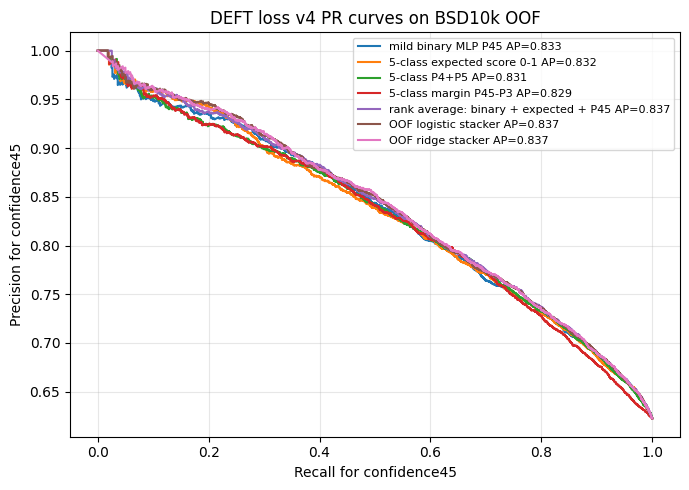

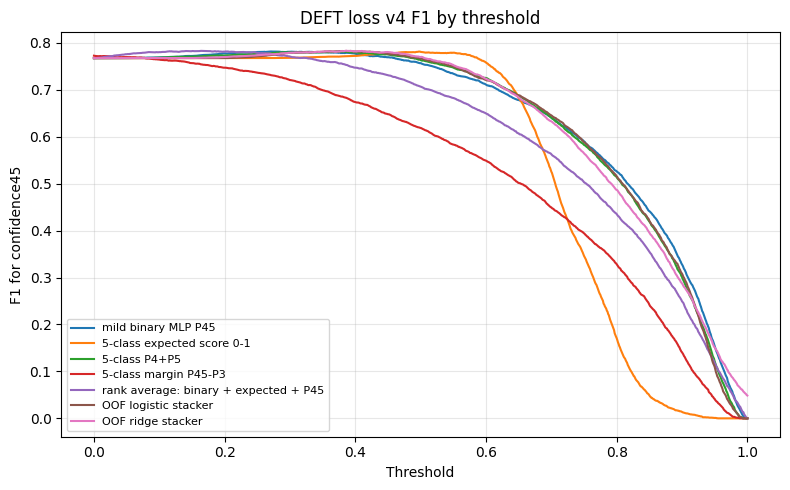

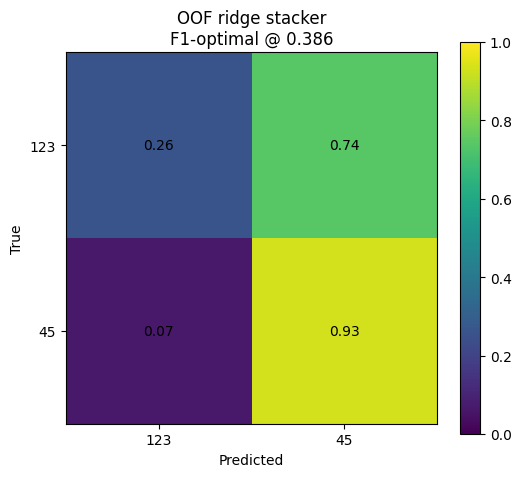

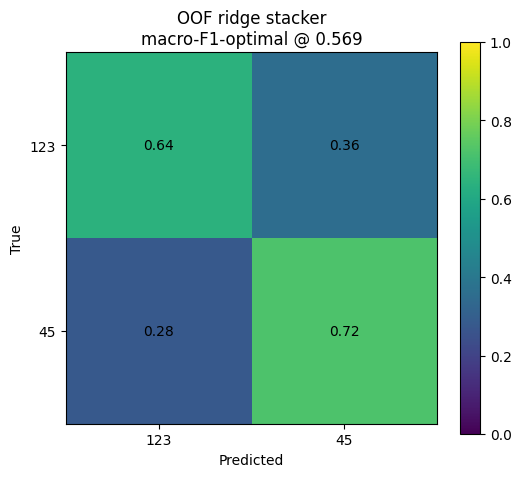

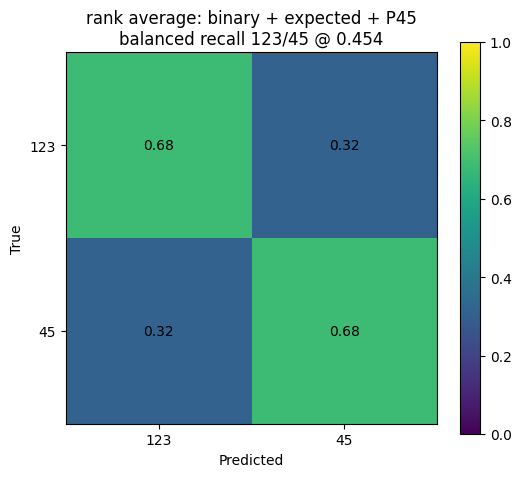

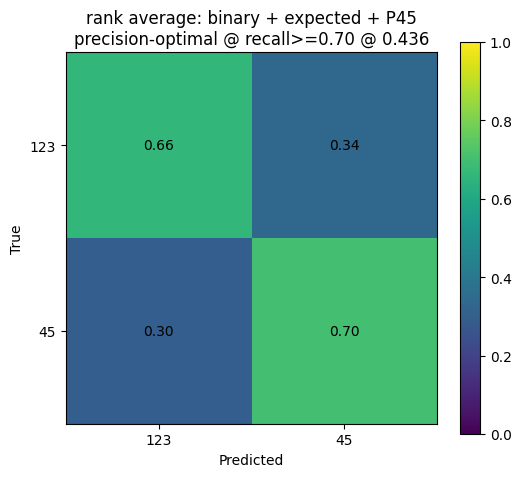

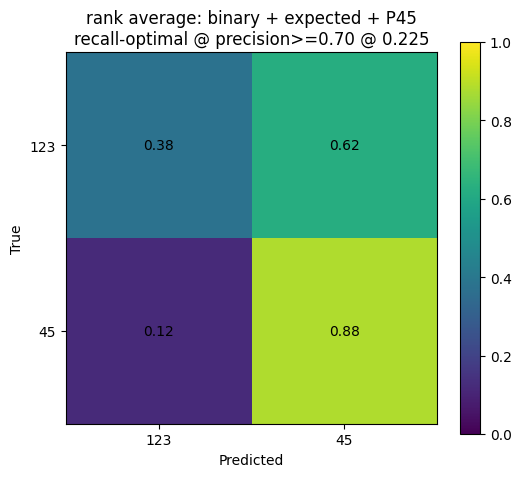

,method,score_column,objective,threshold,accuracy,precision,recall,f1,macro_precision,macro_recall,macro_f1,recall_123,recall_45,auc_pr,auc_roc,recall_gap,min_recall
0,OOF ridge stacker,ridge_stacker_score45,F1-optimal,0.386,0.678715,0.675343,0.931975,0.783171,0.687315,0.596459,0.581617,0.260943,0.931975,0.837451,0.753128,NaN,NaN
1,OOF ridge stacker,ridge_stacker_score45,macro-F1-optimal,0.569,0.691402,0.768582,0.721595,0.744348,0.675701,0.681596,0.677573,0.641596,0.721595,0.837451,0.753128,NaN,NaN
2,rank average: binary + expected + P45,rank_avg_binary_expected_p45,balanced recall 123/45,0.454,0.684465,0.781459,0.684650,0.729859,0.674766,0.684405,0.675297,0.684160,0.684650,0.836610,0.752745,0.000491,0.68416
3,rank average: binary + expected + P45,rank_avg_binary_expected_p45,precision-optimal @ recall>=0.70,0.436,0.686382,0.774534,0.700044,0.735407,0.673741,0.681945,0.675232,0.663845,0.700044,0.836610,0.752745,NaN,NaN
4,rank average: binary + expected + P45,rank_avg_binary_expected_p45,recall-optimal @ precision>=0.70,0.225,0.691128,0.700175,0.881249,0.780345,0.679273,0.629379,0.630105,0.377509,0.881249,0.836610,0.752745,NaN,NaN


In [9]:
plt.figure(figsize=(7, 5))
for method, col in score_specs:
    precision, recall, _ = precision_recall_curve(y, score_df[col].to_numpy(dtype=float))
    ap = average_precision_score(y, score_df[col].to_numpy(dtype=float))
    plt.plot(recall, precision, label=f'{method} AP={ap:.3f}')
plt.xlabel('Recall for confidence45')
plt.ylabel('Precision for confidence45')
plt.title('DEFT loss v4 PR curves on BSD10k OOF')
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'deft_loss_v4_pr_curves.png', dpi=180)
plt.show()

plt.figure(figsize=(8, 5))
for method, sweep in sweep_tables.items():
    plt.plot(sweep['threshold'], sweep['f1'], label=method)
plt.xlabel('Threshold')
plt.ylabel('F1 for confidence45')
plt.title('DEFT loss v4 F1 by threshold')
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'deft_loss_v4_threshold_f1.png', dpi=180)
plt.show()

def plot_cm_for_row(row, filename):
    score = score_df[row['score_column']].to_numpy(dtype=float)
    pred = (score >= float(row['threshold'])).astype(int)
    cm = confusion_matrix(y, pred, labels=[0, 1])
    cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    plt.figure(figsize=(5.5, 4.8))
    plt.imshow(cm_norm, vmin=0, vmax=1)
    plt.title(f"{row['method']}\n{row['objective']} @ {row['threshold']:.3f}")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks([0, 1], ['123', '45'])
    plt.yticks([0, 1], ['123', '45'])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, f'{cm_norm[i, j]:.2f}', ha='center', va='center')
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(PLOT_DIR / filename, dpi=180)
    plt.show()
    return cm, cm_norm

best_by_objective = []
for objective in threshold_summary['objective'].unique():
    subset = threshold_summary[threshold_summary['objective'] == objective].copy()
    if objective == 'precision-optimal @ recall>=0.70':
        best = subset.sort_values(['precision', 'f1', 'macro_f1'], ascending=[False, False, False]).iloc[0]
    elif objective == 'recall-optimal @ precision>=0.70':
        best = subset.sort_values(['recall', 'f1', 'macro_f1'], ascending=[False, False, False]).iloc[0]
    elif objective == 'balanced recall 123/45':
        tmp = subset.assign(min_recall=subset[['recall_123', 'recall_45']].min(axis=1), recall_gap=(subset['recall_123'] - subset['recall_45']).abs())
        best = tmp.sort_values(['min_recall', 'macro_f1', 'recall_gap'], ascending=[False, False, True]).iloc[0]
    elif objective == 'macro-F1-optimal':
        best = subset.sort_values(['macro_f1', 'macro_recall', 'f1'], ascending=[False, False, False]).iloc[0]
    else:
        best = subset.sort_values(['f1', 'precision', 'macro_f1'], ascending=[False, False, False]).iloc[0]
    best_by_objective.append(best.to_dict())
    safe_name = objective.replace(' ', '_').replace('/', '_').replace('>=', 'ge').replace('@', 'at')
    cm, cm_norm = plot_cm_for_row(best, f'best_{safe_name}_confusion_row_normalized.png')
    pd.DataFrame(cm, index=['true_123', 'true_45'], columns=['pred_123', 'pred_45']).to_csv(REPORT_DIR / f'best_{safe_name}_confusion_counts.csv', encoding='utf-8-sig')
    pd.DataFrame(cm_norm, index=['true_123', 'true_45'], columns=['pred_123', 'pred_45']).to_csv(REPORT_DIR / f'best_{safe_name}_confusion_row_normalized.csv', encoding='utf-8-sig')

best_by_objective_df = pd.DataFrame(best_by_objective)
best_by_objective_df.to_csv(REPORT_DIR / 'deft_loss_v4_best_by_objective.csv', index=False, encoding='utf-8-sig')
display(best_by_objective_df)

## Save Korean report

In [10]:
best_f1 = threshold_summary[threshold_summary['objective'] == 'F1-optimal'].sort_values(['f1', 'precision'], ascending=[False, False]).iloc[0]
best_macro = threshold_summary[threshold_summary['objective'] == 'macro-F1-optimal'].sort_values(['macro_f1', 'macro_recall'], ascending=[False, False]).iloc[0]
best_balanced = best_by_objective_df[best_by_objective_df['objective'] == 'balanced recall 123/45'].iloc[0]

report_lines = []
report_lines.append('# DEFT Loss v4 OOF Score Stacking Report')
report_lines.append('')
report_lines.append('## 실험 설정')
report_lines.append('- base input: 04 feature set')
report_lines.append('- base model: 04 MLP structure')
report_lines.append('- loss weight: confidence 1 = 5.0, confidence 2 = 1.5, confidence 3/4/5 = 1.0')
report_lines.append('- target: confidence 123 vs 45')
report_lines.append('- evaluation: BSD10k OOF')
report_lines.append('')
report_lines.append('## 핵심 결과')
report_lines.append(f"- best F1 method: {best_f1['method']} threshold={best_f1['threshold']:.4f} f1={best_f1['f1']:.4f} precision={best_f1['precision']:.4f} recall={best_f1['recall']:.4f}")
report_lines.append(f"- best macro-F1 method: {best_macro['method']} threshold={best_macro['threshold']:.4f} macro_f1={best_macro['macro_f1']:.4f} recall_123={best_macro['recall_123']:.4f} recall_45={best_macro['recall_45']:.4f}")
report_lines.append(f"- best balanced recall method: {best_balanced['method']} threshold={best_balanced['threshold']:.4f} recall_123={best_balanced['recall_123']:.4f} recall_45={best_balanced['recall_45']:.4f}")
report_lines.append('')
report_lines.append('## 목적별 threshold')
report_lines.append('```text')
report_lines.append(best_by_objective_df[['objective', 'method', 'threshold', 'precision', 'recall', 'f1', 'macro_f1', 'recall_123', 'recall_45', 'auc_pr']].round(4).to_string(index=False))
report_lines.append('```')
report_lines.append('')
report_lines.append('## 저장 파일')
report_lines.append('- predictions: `deft논문기반_실험/deft_loss_v4_outputs/predictions/BSD10k_oof_deft_loss_v4_scores_with_stackers.csv`')
report_lines.append('- threshold summary: `deft논문기반_실험/deft_loss_v4_outputs/reports/deft_loss_v4_threshold_summary.csv`')
report_lines.append('- best thresholds: `deft논문기반_실험/deft_loss_v4_outputs/reports/deft_loss_v4_best_by_objective.csv`')
report_lines.append('- PR curves: `deft논문기반_실험/deft_loss_v4_outputs/plots/deft_loss_v4_pr_curves.png`')
report_text = '\n'.join(report_lines)
(REPORT_DIR / 'deft_loss_v4_report_ko.md').write_text(report_text, encoding='utf-8')
(EXP_DIR / 'deft_loss_v4_report_ko.md').write_text(report_text, encoding='utf-8')

summary = {
    'feature_description': FEATURE_DESCRIPTION,
    'model_description': MODEL_DESCRIPTION,
    'loss_weights': LOSS_WEIGHTS,
    'stack_features': stack_features,
    'best_f1': best_f1.to_dict(),
    'best_macro_f1': best_macro.to_dict(),
    'best_by_objective': best_by_objective,
}
(REPORT_DIR / 'deft_loss_v4_summary.json').write_text(json.dumps(summary, indent=2, ensure_ascii=False, default=float), encoding='utf-8')
print(report_text)
print('saved:', OUT_DIR)

# DEFT Loss v4 OOF Score Stacking Report

## 실험 설정
- base input: 04 feature set
- base model: 04 MLP structure
- loss weight: confidence 1 = 5.0, confidence 2 = 1.5, confidence 3/4/5 = 1.0
- target: confidence 123 vs 45
- evaluation: BSD10k OOF

## 핵심 결과
- best F1 method: OOF ridge stacker threshold=0.3860 f1=0.7832 precision=0.6753 recall=0.9320
- best macro-F1 method: OOF ridge stacker threshold=0.5690 macro_f1=0.6776 recall_123=0.6416 recall_45=0.7216
- best balanced recall method: rank average: binary + expected + P45 threshold=0.4540 recall_123=0.6842 recall_45=0.6847

## 목적별 threshold
```text
                       objective                                method  threshold  precision  recall     f1  macro_f1  recall_123  recall_45  auc_pr
                      F1-optimal                     OOF ridge stacker      0.386     0.6753  0.9320 0.7832    0.5816      0.2609     0.9320  0.8375
                macro-F1-optimal                     OOF ridge stacker      0.569     0.7686  0.